In [2]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [3]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/!_calibration


Epoch [100/10000], Loss: 0.2521
Epoch [200/10000], Loss: 0.2373
Epoch [300/10000], Loss: 0.2212
Epoch [400/10000], Loss: 0.2026
Epoch [500/10000], Loss: 0.1789
Epoch [600/10000], Loss: 0.1589
Epoch [700/10000], Loss: 0.1398
Epoch [800/10000], Loss: 0.1260
Epoch [900/10000], Loss: 0.1167
Epoch [1000/10000], Loss: 0.1068
Epoch [1100/10000], Loss: 0.0993
Epoch [1200/10000], Loss: 0.0923
Epoch [1300/10000], Loss: 0.0878
Epoch [1400/10000], Loss: 0.0834
Epoch [1500/10000], Loss: 0.0770
Epoch [1600/10000], Loss: 0.0735
Epoch [1700/10000], Loss: 0.0686
Epoch [1800/10000], Loss: 0.0656
Epoch [1900/10000], Loss: 0.0633
Epoch [2000/10000], Loss: 0.0596
Epoch [2100/10000], Loss: 0.0568
Epoch [2200/10000], Loss: 0.0522
Epoch [2300/10000], Loss: 0.0501
Epoch [2400/10000], Loss: 0.0484
Epoch [2500/10000], Loss: 0.0452
Epoch [2600/10000], Loss: 0.0438
Epoch [2700/10000], Loss: 0.0419
Epoch [2800/10000], Loss: 0.0393
Epoch [2900/10000], Loss: 0.0380
Epoch [3000/10000], Loss: 0.0360
Epoch [3100/10000],

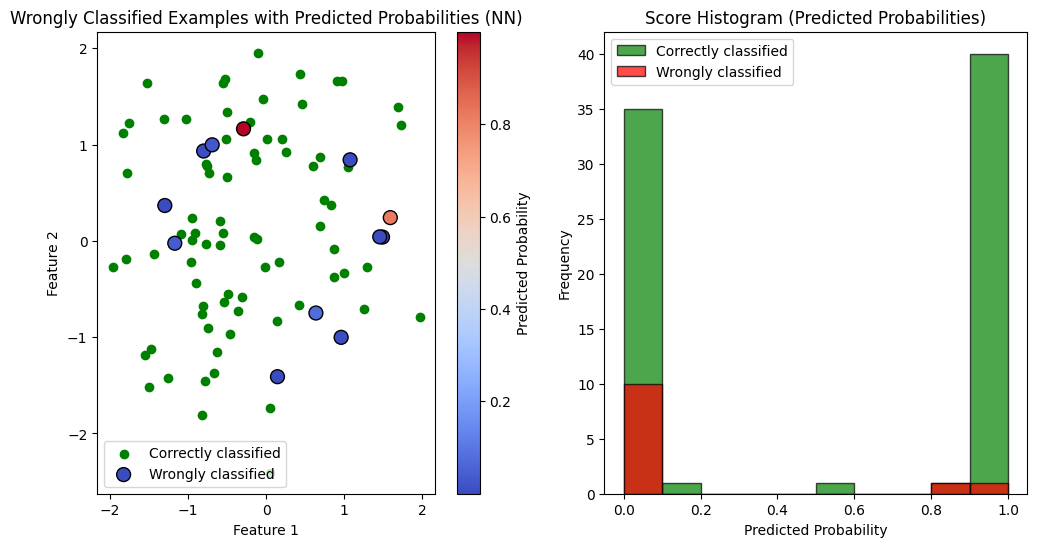

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Create Toy Data
X, y = make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=42)
y = y.reshape(-1, 1)  # Reshape labels to be column vector

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Define the Neural Network model
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)  # Hidden layer
        self.relu = nn.ReLU()                            # ReLU activation
        self.output = nn.Linear(hidden_size, output_size)  # Output layer (for binary classification)
        self.sigmoid = nn.Sigmoid()                      # Sigmoid activation for probabilities
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# Hyperparameters
input_size = 2  # Since we have two features
hidden_size = 1000
output_size = 1  # For binary classification (0 or 1)
learning_rate = 0.01
num_epochs = 10000

# Model, loss function, and optimizer
model = SimpleNN(input_size, hidden_size, output_size)
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training the model
losses = []
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = test_outputs.round()  # Rounds the probabilities to get predicted classes (0 or 1)

# Extract the wrongly classified points
wrong_classified_idx = (test_preds != y_test_tensor).squeeze().nonzero(as_tuple=True)[0]
correct_classified_idx = (test_preds == y_test_tensor).squeeze().nonzero(as_tuple=True)[0]

# Visualize the Results

# Scatter plot for correct and wrongly classified points
plt.figure(figsize=(12, 6))

# Correctly classified points
plt.subplot(1, 2, 1)
plt.scatter(X_test[correct_classified_idx, 0], X_test[correct_classified_idx, 1], color='green', label='Correctly classified')

# Wrongly classified points and their predicted probabilities
wrong_probs = test_outputs[wrong_classified_idx].numpy()
scatter = plt.scatter(X_test[wrong_classified_idx, 0], X_test[wrong_classified_idx, 1], c=wrong_probs, cmap='coolwarm', edgecolor='k', label='Wrongly classified', s=100)
plt.colorbar(scatter, label='Predicted Probability')
plt.title("Wrongly Classified Examples with Predicted Probabilities (NN)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# Score histogram for correct and wrongly classified points
plt.subplot(1, 2, 2)
correct_probs = test_outputs[correct_classified_idx].numpy()
plt.hist(correct_probs, bins=10, alpha=0.7, label='Correctly classified', color='green', edgecolor='k')
plt.hist(wrong_probs, bins=10, alpha=0.7, label='Wrongly classified', color='red', edgecolor='k')
plt.title("Score Histogram (Predicted Probabilities)")
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()

# Save and show the plots
output_path = OUTPUT_DIR  # Replace with the actual directory or ask for user input
Path(output_path).mkdir(parents=True, exist_ok=True)
plt.savefig(Path(output_path) / "nn_wrong_classified_with_histogram.png", bbox_inches='tight', pad_inches=0)
plt.show()